In [115]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from astropy.table import Table, join, vstack
from astropy.coordinates import SkyCoord
import astropy.units as u
import fitsio
import numpy.lib.recfunctions as rfn
from scipy.optimize import curve_fit


from stats_functions import *
# from TF_photoCorrect import *

In [107]:
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['figure.titlesize'] = 16
matplotlib.rcParams['xtick.labelsize'] = 14
matplotlib.rcParams['ytick.labelsize'] = 14
matplotlib.rcParams['font.size'] = 16

## read in tables

In [4]:
# FP/SDSS crossmatch table
DATA_DIR = '/pscratch/sd/n/nravi/BTFR/'
fp_sdss = Table.read(DATA_DIR + 'FP_in_sdss.csv')
fp_sdss[:5]

targetid,filename,target_ra,target_dec,program,survey,healpix,ra,dec,brickid,brick_objid,z,z_err,zcmb,deltachi2,circ_radius,circ_radius_err,kcorr_sdss_r,mag_r,mag_r_err,ppxf_vdisp,ppxf_vdisp_err,halpha_ew,halpha_ew_ivar,Zhu_alpha,Zhu_alpha_err,Zhu_alpha_circ,Zhu_alpha_circ_err,age,snr_r,sersic,ba_ratio,mag_g,mag_z,zcat_primary,NgroupT17,zcmb_group,zsun,sigma_corr_exp,sigma_corr_exp_err,r,er,i,ei,s,es,absmag_r,ppxf_rel_err,full_index,FPcalibrator,primaryVdisp,Sn,logdist,logdist_err,logdist_alpha,std_fiber_ra,std_fiber_dec,coadd_numexp,coadd_exptime,coadd_numtile,bgs_target,ppxf_chi2,ppxf_snr,dnr_snr,ppxf_dof,FP_out_index,region,MJD,PLATE,FIBERID,RUN2D,portsmouth_SIGMA_STARS,portsmouth_SIGMA_STARS_ERR,portsmouth_CHISQ,sdss_pipeline_VDISP,sdss_pipeline_VDISP_ERR,sdss_pipeline_VDISP_DOF,sdss_pipeline_VDISPCHI2,PLUG_RA,PLUG_DEC,BESTOBJID,Tempel_GalID,Tempel_objID,Tempel_GroupID,Tempel_Ngal,sdss_objid,sdss_SIGMA_STARS,sdss_SIGMA_STARS_ERR,sdss_logdist,sdss_logdist_err,sdss_logdist_corr,sdss_logdist_corr_err,sdss_zhelio,sdss_zhelioerr,sdss_s,sdss_es,sdss_Sn,sdss_IDgroupT17,sdss_NgroupT17,sdss_zcmb
int64,str71,float64,float64,str6,str7,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str5,str5,float64,float64,float64,float64,float64,float64,int64,float64,int64,int64,float64,float64,float64,float64,int64,str5,float64,float64,float64,str7,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64
2803534588280832,iron/healpix/main/dark/48/4839/redrock-main-dark-4839.fits,122.524662795403,25.2888044375684,dark,main,4839,122.524668874068,25.2888074640477,471821,4342,0.0555475307956713,9.15205814417007e-06,0.0563024671191554,21607.3362458595,3.1493397200494537,0.0017979750534072,-0.2589706,15.526277174516869,0.0005518705218117,141.48980047299466,5.517093237166566,0.37615487,214.8204,-0.022,0.003,-0.0220006313062112,0.003,12.871886,35.277607,3.76677,0.9214158562697452,16.380682994923745,14.889824818174244,t,1.0,0.0563024671191554,-0.0007146971127911,-0.06,0.03,0.3818430579187416,0.0002565411777174,2.4492703580430657,0.0090145161839091,2.1675210385364774,0.0189023626049733,4.301255830572273,0.0389928688762239,5,True,True,1.0,0.0807232792082026,0.1012927038142599,-0.4574160928296319,0.0,0.0,1,788.176,1,0,0.8643056699586599,8.333220927050476,1.6743603120544213,2453.0,5,south,52705.0,1265.0,587.0,26,143.88759,5.5592356,0.77343524,141.32664,6.8442507,2117.0,1470.956,122.52469,25.288812,1237660958107369915,293235.0,1237660958107369915,0.0,1.0,1237660958107369915,143.88759,5.55924,0.076371,0.100723,0.061062,0.098944,0.055535,1.53114e-05,2.18082,0.01678,0.96474,0.0,1,0.05629
2842436409753604,iron/healpix/main/dark/261/26135/redrock-main-dark-26135.fits,195.45180538397,-3.6731256969304704,dark,main,26135,195.451786512367,-3.67313245556185,309554,4859,0.0842210801721631,1.24560404724514e-05,0.0854064803795568,22507.3562484793,2.5817761648029705,0.0023083031758904,-0.21889856,16.038834636218954,0.0008122935437594,273.11607973335737,7.722794873086658,0.0,0.0,-0.045,0.002,-0.045227294125291,0.0020000000021265,12.862452,39.703163,6.0,0.7272347257738968,16.957339137299396,15.37756266373846,t,1.0,0.0854064803795568,-0.0010921256034691,-0.06,0.03,0.4617835459289743,0.0003924565717176,2.466632481579744,0.0136744207887246,2.4583212298192527,0.0164779191389378,3.8662057070929663,0.0282766026834685,1394,True,True,1.0,-0.1550282877886735,0.1078083054873674,-0.5652771433476149,0.0,0.0,1,1273.06,1,0,1.0449177268131544,5.370203781462284,1.6303538534250666,2298.0,1375,south,51692.0,339.0,208.0,26,264.68625,7.470901,0.9245463,

In [5]:
manga = Table.read(DATA_DIR + '/Elliptical_sphdisk_refitspirals_BPT_illustris_v11.fits')
manga[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

## match manga and fp galaxies

In [6]:
fp_coords = SkyCoord(ra=fp_sdss['PLUG_RA'], dec=fp_sdss['PLUG_DEC'], unit=u.degree)

In [31]:
manga['FP_SDSS_idx'] = np.ones(len(manga), dtype='int')*-999
manga['FP_SDSS_dist'] = np.ones(len(manga))*np.nan
for i in tqdm(range(len(manga))):
    
    manga_coords = SkyCoord(ra=manga['objra'][i], 
                          dec=manga['objdec'][i], 
                          unit=u.degree)

    sep2d = manga_coords.separation(fp_coords)

    closest_match = np.argmin(sep2d)
    # print(closest_match)
    # test = sep2d[closest_match]
    
    manga['FP_SDSS_idx'][i] = closest_match
    manga['FP_SDSS_dist'][i] = sep2d[closest_match].to(u.arcmin).value
    
    # tf_combined['SKY_FIBER_DIST'][obs_idx] = sep2d
    # tf_combined['SKY_FIBER_DIST_R26'][obs_idx] = 2*sep2d.to('arcmin')/(SGA['D26'][sga_idx]*u.arcmin)


100%|██████████| 11273/11273 [00:26<00:00, 428.75it/s]


(array([337.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   2.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          0.,   0.,   3.,   1.,   1.,   0.,   0.,   0.,   1.,   0.,   1.,
          0.,   1.,   0.,   0.,   0.,   1.,   0.,   0.,   1.,   0.,   0.,
          3.,   1.,   1.,   2.,   1.,   1.,   1.,   0.,   0.,   1.,   0.,
          1.,   1.,   1.,   0.,   3.,   2.,   2.,   0.,   0.,   0.,   0.,
          0.,   1.,   1.,   3.,   1.,   2.,   2.,   0.,   1.,   1.,   1.]),
 array([0.        , 0.01010101, 0.02020202, 0.03030303, 0.04040404,
        0.05050505, 0.06060606, 0.07070707, 0.08080808, 0.09090909,
        0.1010101 , 0.11111111, 0.12121212, 0.13131313, 0.14141414,
        0.15151515, 0.16161616, 0.17171717, 0.18181818, 0.19191919,
        0.2020202 , 0.21212121, 0.22222222, 0.23232323, 0.24

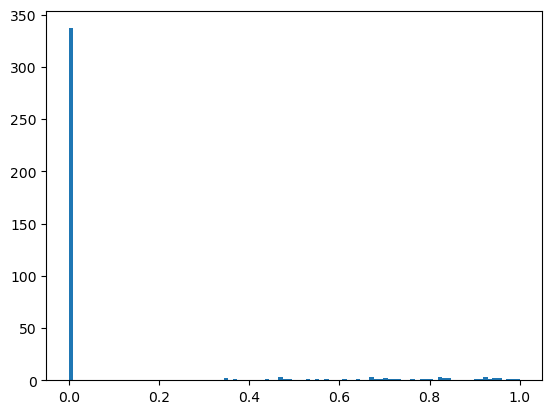

In [32]:
plt.hist(manga['FP_SDSS_dist'], bins=np.linspace(0,1,100))

In [33]:
# let's consider < 0.01 arcmin to be a good match
manga_matches = manga[manga['FP_SDSS_dist'] < 0.01]
# check for uniquenesss in this set
unique_idx, counts = np.unique(manga_matches['FP_SDSS_idx'], return_counts=1)

(array([311.,   0.,   0.,   8.,   0.,   0.,   2.,   0.,   0.,   1.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

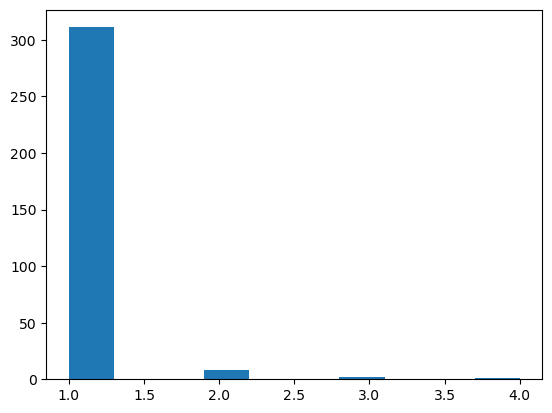

In [35]:
plt.hist(counts)

(array([308.,   0.,   0.,   0.,   0.,   6.,   0.,   0.,   0.,   1.]),
 array([1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4, 2.6, 2.8, 3. ]),
 <BarContainer object of 10 artists>)

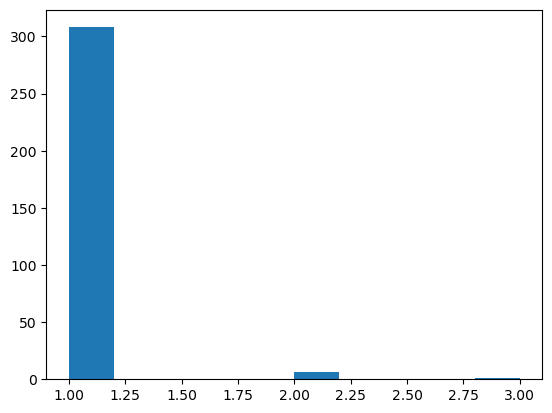

In [36]:
# check for galaxy targets
manga_matches = manga_matches[manga_matches['mngtarg1'] > 0]
unique_idx, counts = np.unique(manga_matches['FP_SDSS_idx'], return_counts=1)
plt.hist(counts)

In [38]:
unique_idx[counts>1]

393
6594
7561
8382
8660
8981
9165


## investigate multiple matches
* FP_SDSS idx 393 corresponds to manga 10513-1901, 9512-6104 which are the same gal
  * keep 9512-6104, remove 10513-1901
* idx 6594 corresponds to manga 11823-6104, 11950-1901 are the same gal
  * keep 11950-1901
* idx 7561 --> manga 7958-3703, 9185-3702 (same gal)
  * neither made it into spiral or elliptical sample, cut both and ignore
* idx 8382 --> 8256-3704, 8274-3704, 8451-3704 (same gal)
  * none in spiral/elliptical sample, cut all 3 and ignore
* idx 8660 --> manga 8249-12705, 8250-3702
  * keep 8250-3702
* idx 8981 --> manga 11827-3701, 8325-6103
  * keep 8325-6103 (in elliptical sample)
* idx 9165 --> manga 11827-3703, 9864-3701
  * keep 9864-3701 (in elliptical sample)

In [62]:
fp_sdss[9165]

targetid,filename,target_ra,target_dec,program,survey,healpix,ra,dec,brickid,brick_objid,z,z_err,zcmb,deltachi2,circ_radius,circ_radius_err,kcorr_sdss_r,mag_r,mag_r_err,ppxf_vdisp,ppxf_vdisp_err,halpha_ew,halpha_ew_ivar,Zhu_alpha,Zhu_alpha_err,Zhu_alpha_circ,Zhu_alpha_circ_err,age,snr_r,sersic,ba_ratio,mag_g,mag_z,zcat_primary,NgroupT17,zcmb_group,zsun,sigma_corr_exp,sigma_corr_exp_err,r,er,i,ei,s,es,absmag_r,ppxf_rel_err,full_index,FPcalibrator,primaryVdisp,Sn,logdist,logdist_err,logdist_alpha,std_fiber_ra,std_fiber_dec,coadd_numexp,coadd_exptime,coadd_numtile,bgs_target,ppxf_chi2,ppxf_snr,dnr_snr,ppxf_dof,FP_out_index,region,MJD,PLATE,FIBERID,RUN2D,portsmouth_SIGMA_STARS,portsmouth_SIGMA_STARS_ERR,portsmouth_CHISQ,sdss_pipeline_VDISP,sdss_pipeline_VDISP_ERR,sdss_pipeline_VDISP_DOF,sdss_pipeline_VDISPCHI2,PLUG_RA,PLUG_DEC,BESTOBJID,Tempel_GalID,Tempel_objID,Tempel_GroupID,Tempel_Ngal,sdss_objid,sdss_SIGMA_STARS,sdss_SIGMA_STARS_ERR,sdss_logdist,sdss_logdist_err,sdss_logdist_corr,sdss_logdist_corr_err,sdss_zhelio,sdss_zhelioerr,sdss_s,sdss_es,sdss_Sn,sdss_IDgroupT17,sdss_NgroupT17,sdss_zcmb
int64,str71,float64,float64,str6,str7,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str5,str5,float64,float64,float64,float64,float64,float64,int64,float64,int64,int64,float64,float64,float64,float64,int64,str5,float64,float64,float64,str7,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64
39633252314516932,iron/healpix/main/bright/107/10718/redrock-main-bright-10718.fits,213.887158617508,50.1810193192264,bright,main,10718,213.887169400493,50.18102853788729,585366,3524,0.0441513009679656,6.48976389527948e-06,0.0445990922947963,87193.9250524244,5.029299438606063,0.0029161649223055,-0.2537701,14.262244873375897,0.0004760337973619,236.19823447115368,4.64269378215939,0.0,0.0,-0.04,0.001,-0.0403998103593053,0.001000000002986,12.95023,67.91242,4.73862,0.6926435574878267,15.143183318080096,13.682682261165697,t,1.0,0.0445990922947963,-0.000428672904403,-0.06,0.03,0.4898697985852845,0.0002588266219108,2.536679556199137,0.0071428395294708,2.377875272432193,0.00884071157165,3.56067334415617,0.0196559207673772,96016,True,True,1.0,0.0417654955909713,0.0994101859348029,-0.3947997412280101,0.0,0.0,2,1936.89,1,514,1.360728180188515,13.8732155044796,1.6910009728540354,2514.0,94292,north,52725.0,1045.0,251.0,26,257.5565,5.037819,0.82156837,231.77351,5.5184474,2117.0,1361.9066,213.88719,50.181013,1237659118249050121,128918.0,1237659118249050121,0.0,1.0,1237659118249050121,257.5565,5.03782,0.009422,0.098497,0.013253,0.096068,0.044128,1.24744e-05,2.42963,0.00849,1.0,0.0,1,0.044576


In [64]:
manga_matches[manga_matches['FP_SDSS_idx'] == 9165]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot,FP_SDSS_idx,FP_SDSS_dist
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

In [65]:
rem = ['10513-1901', '11823-6104', '7958-3703', '9185-3702', '8256-3704', '8274-3704', '8451-3704',
       '8249-12705', '11827-3701', '11827-3703']

for plateifu in rem:

    manga_matches['FP_SDSS_idx'][manga_matches['plateifu'] == plateifu] = -999
    manga_matches['FP_SDSS_dist'][manga_matches['plateifu'] == plateifu] = np.nan

In [68]:
manga_matches = manga_matches[manga_matches['FP_SDSS_idx'] >= 0]

## stats of the good matches between FP/SDSS/MaNGA

In [70]:
len(manga_matches[manga_matches['spiral_mask']==1])

4

In [71]:
len(manga_matches[manga_matches['elliptical_mask'] ==1])

257

In [73]:
ellipticals = manga_matches[manga_matches['elliptical_mask'] ==1]

### grab the desi/sdss values from the table

In [83]:
ellipticals['ppxf_vdisp'] = np.ones(len(ellipticals))*np.nan
ellipticals['ppxf_vdisp_err'] = np.ones(len(ellipticals))*np.nan

ellipticals['portsmouth_SIGMA_STARS'] = np.ones(len(ellipticals))*np.nan
ellipticals['portsmouth_SIGMA_STARS_ERR'] = np.ones(len(ellipticals))*np.nan

ellipticals['sdss_pipeline_VDISP'] = np.ones(len(ellipticals))*np.nan
ellipticals['sdss_pipeline_VDISP_ERR'] = np.ones(len(ellipticals))*np.nan


ellipticals['sdss_SIGMA_STARS'] = np.ones(len(ellipticals))*np.nan
ellipticals['sdss_SIGMA_STARS_ERR'] = np.ones(len(ellipticals))*np.nan

for i in range(len(ellipticals)):

    fp_idx = ellipticals['FP_SDSS_idx'][i]

    ellipticals['ppxf_vdisp'][i] = fp_sdss['ppxf_vdisp'][fp_idx]
    ellipticals['ppxf_vdisp_err'][i] = fp_sdss['ppxf_vdisp_err'][fp_idx]
    
    ellipticals['portsmouth_SIGMA_STARS'][i] = fp_sdss['portsmouth_SIGMA_STARS'][fp_idx]
    ellipticals['portsmouth_SIGMA_STARS_ERR'][i] = fp_sdss['portsmouth_SIGMA_STARS_ERR'][fp_idx]
    
    ellipticals['sdss_pipeline_VDISP'][i] = fp_sdss['sdss_pipeline_VDISP'][fp_idx]
    ellipticals['sdss_pipeline_VDISP_ERR'][i]= fp_sdss['sdss_pipeline_VDISP_ERR'][fp_idx]
    
    
    ellipticals['sdss_SIGMA_STARS'][i] = fp_sdss['sdss_SIGMA_STARS'][fp_idx]
    ellipticals['sdss_SIGMA_STARS_ERR'][i] = fp_sdss['sdss_SIGMA_STARS_ERR'][fp_idx]

/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/astropy/table/column.py:1383: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value


### desi vs sdss vdisp for these

Text(0, 0.5, 'SDSS $\\sigma_*$ [km/s]')

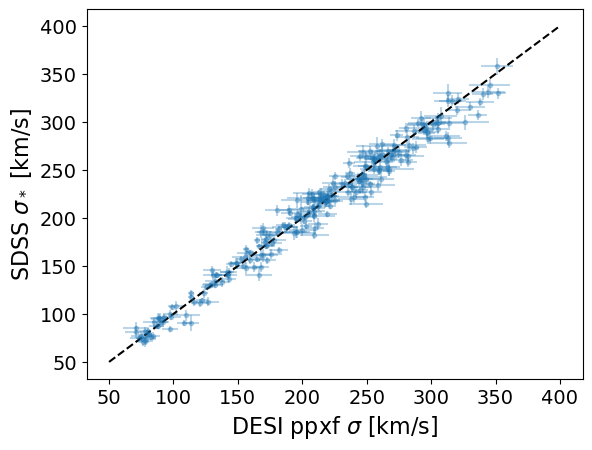

In [108]:
plt.errorbar(ellipticals['ppxf_vdisp'], ellipticals['sdss_SIGMA_STARS'], xerr=ellipticals['ppxf_vdisp_err'], yerr=ellipticals['sdss_SIGMA_STARS_ERR'],
            linestyle='none', alpha=0.3, marker='.')
plt.plot([50,400],[50,400], linestyle='--', color='k')
plt.xlabel(r'DESI ppxf $\sigma$ [km/s]')
plt.ylabel(r'SDSS $\sigma_*$ [km/s]')

In [123]:
counts, bins = np.histogram(ellipticals['ppxf_vdisp'] - ellipticals['sdss_SIGMA_STARS'], 
                            bins=int(np.sqrt(len(ellipticals))+1), density=True)
bin_ctrs = (bins[1:] + bins[:-1])/2
params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(ellipticals['ppxf_vdisp'] - ellipticals['sdss_SIGMA_STARS']),
                                np.std(ellipticals['ppxf_vdisp'] - ellipticals['sdss_SIGMA_STARS'])])
print(params)

[-0.21541828 10.63460316]


Text(0.5, 0, '$\\sigma_{\\rm DESI} - \\sigma_{\\rm SDSS}$ [km/s]')

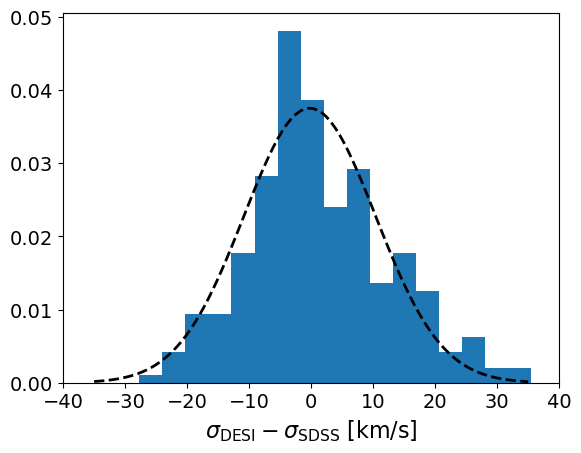

In [125]:
plt.stairs(counts, bins, fill='tab:blue')
plt.plot(np.linspace(-35,35,100), gaussian(np.linspace(-35,35,100), params[0], params[1]),
        color='k', linestyle='--', linewidth=2)
plt.xlim(-40,40)
plt.xlabel(r'$\sigma_{\rm DESI} - \sigma_{\rm SDSS}$ [km/s]')

### manga vdisp vs sdss

(50.0, 400.0)

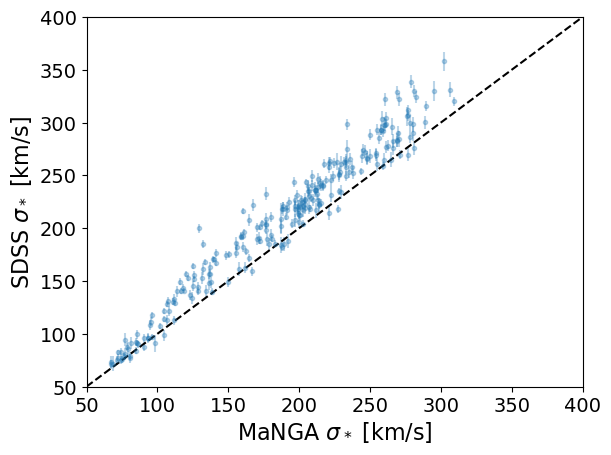

In [126]:
plt.errorbar(ellipticals['star_sigma'], ellipticals['sdss_SIGMA_STARS'], 
             # xerr=ellipticals['star_sigma_err'], 
             yerr=ellipticals['sdss_SIGMA_STARS_ERR'],
            linestyle='none', 
            marker='.',
             alpha=0.3)
plt.plot([50,400],[50,400], linestyle='--', color='k')
plt.xlabel(r'MaNGA $\sigma_*$ [km/s]')
plt.ylabel(r'SDSS $\sigma_*$ [km/s]')
plt.xlim(50,400)
plt.ylim(50,400)

In [127]:
counts, bins = np.histogram(ellipticals['star_sigma'] - ellipticals['sdss_SIGMA_STARS'], 
                            bins=int(np.sqrt(len(ellipticals))+1), density=True)
bin_ctrs = (bins[1:] + bins[:-1])/2
params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(ellipticals['star_sigma'] - ellipticals['sdss_SIGMA_STARS']),
                                np.std(ellipticals['star_sigma'] - ellipticals['sdss_SIGMA_STARS'])])
print(params)

[-19.91047425  15.05321343]


Text(0.5, 0, '$\\sigma_{\\rm MaNGA} - \\sigma_{\\rm SDSS}$ [km/s]')

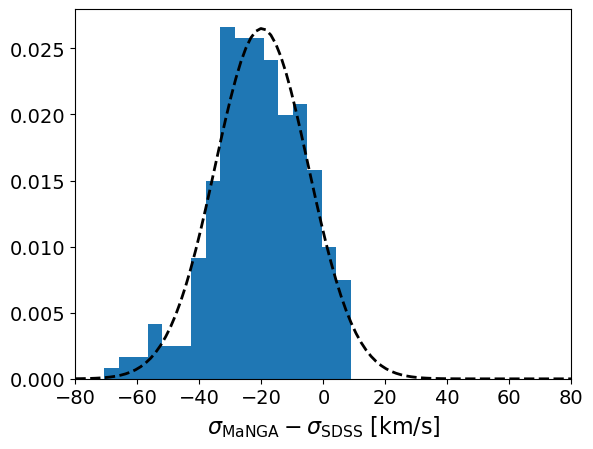

In [132]:
plt.stairs(counts, bins, fill='tab:blue')
plt.plot(np.linspace(-80,80,100), gaussian(np.linspace(-80,80,100), params[0], params[1]),
        color='k', linestyle='--', linewidth=2)
plt.xlim(-80,80)
plt.xlabel(r'$\sigma_{\rm MaNGA} - \sigma_{\rm SDSS}$ [km/s]')

### manga vdisp vs desi

(50.0, 400.0)

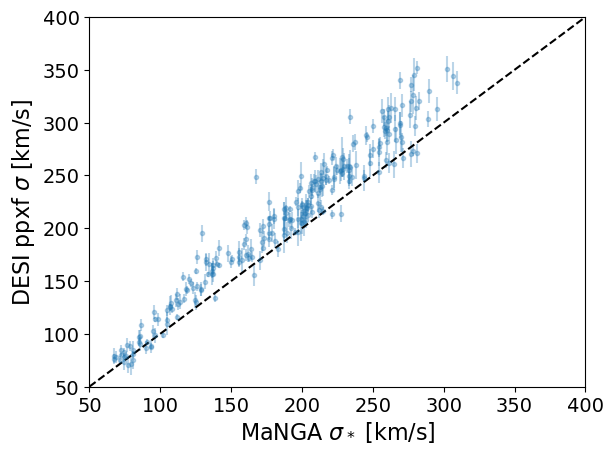

In [133]:
plt.errorbar(ellipticals['star_sigma'], ellipticals['ppxf_vdisp'], 
             # xerr=ellipticals['star_sigma_err'], 
             yerr=ellipticals['ppxf_vdisp_err'],
            linestyle='none', 
            marker='.',
             alpha=0.3)
plt.plot([50,400],[50,400], linestyle='--', color='k')
plt.xlabel(r'MaNGA $\sigma_*$ [km/s]')
plt.ylabel(r'DESI ppxf $\sigma$ [km/s]')
plt.xlim(50,400)
plt.ylim(50,400)

In [134]:
counts, bins = np.histogram(ellipticals['star_sigma'] - ellipticals['ppxf_vdisp'], 
                            bins=int(np.sqrt(len(ellipticals))+1), density=True)
bin_ctrs = (bins[1:] + bins[:-1])/2
params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(ellipticals['star_sigma'] - ellipticals['ppxf_vdisp']),
                                np.std(ellipticals['star_sigma'] - ellipticals['ppxf_vdisp'])])
print(params)

[-20.70564404  16.10804752]


Text(0.5, 0, '$\\sigma_{\\rm MaNGA} - \\sigma_{\\rm DESI}$ [km/s]')

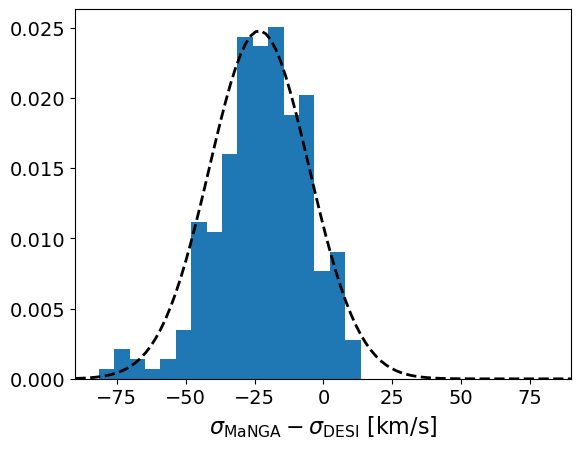

In [136]:
plt.stairs(counts, bins, fill='tab:blue')
plt.plot(np.linspace(-90,90,100), gaussian(np.linspace(-80,80,100), params[0], params[1]),
        color='k', linestyle='--', linewidth=2)
plt.xlim(-90,90)
plt.xlabel(r'$\sigma_{\rm MaNGA} - \sigma_{\rm DESI}$ [km/s]')

In [137]:
len(fp_sdss)

10559